# GPT в нулевых

# Imports

In [5]:
from tqdm import tqdm

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

# Tokenize text data

In [6]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
# print(itos)
# print(vocab_size)


TRAIN LOSS:     0/ 400000: 46.6425
VALIDATION LOSS: 48.316978454589844 
TRAIN LOSS:  1000/ 400000: 3.9021
VALIDATION LOSS: 4.249082565307617 
TRAIN LOSS:  2000/ 400000: 3.6277
VALIDATION LOSS: 3.007415771484375 
TRAIN LOSS:  3000/ 400000: 3.0923
VALIDATION LOSS: 2.3925814628601074 
TRAIN LOSS:  4000/ 400000: 2.7392
VALIDATION LOSS: 2.83514142036438 
TRAIN LOSS:  5000/ 400000: 2.7382
VALIDATION LOSS: 2.974195718765259 
TRAIN LOSS:  6000/ 400000: 2.8743
VALIDATION LOSS: 2.7658979892730713 
TRAIN LOSS:  7000/ 400000: 2.8930
VALIDATION LOSS: 2.553921937942505 
TRAIN LOSS:  8000/ 400000: 2.5142
VALIDATION LOSS: 2.776866912841797 
TRAIN LOSS:  9000/ 400000: 2.7780
VALIDATION LOSS: 2.785698175430298 
TRAIN LOSS: 10000/ 400000: 2.6820
VALIDATION LOSS: 2.7559118270874023 
TRAIN LOSS: 11000/ 400000: 2.9970
VALIDATION LOSS: 2.5506348609924316 
TRAIN LOSS: 12000/ 400000: 2.7991
VALIDATION LOSS: 2.694340229034424 
TRAIN LOSS: 13000/ 400000: 3.1011
VALIDATION LOSS: 3.1379616260528564 
TRAIN LOSS: 14

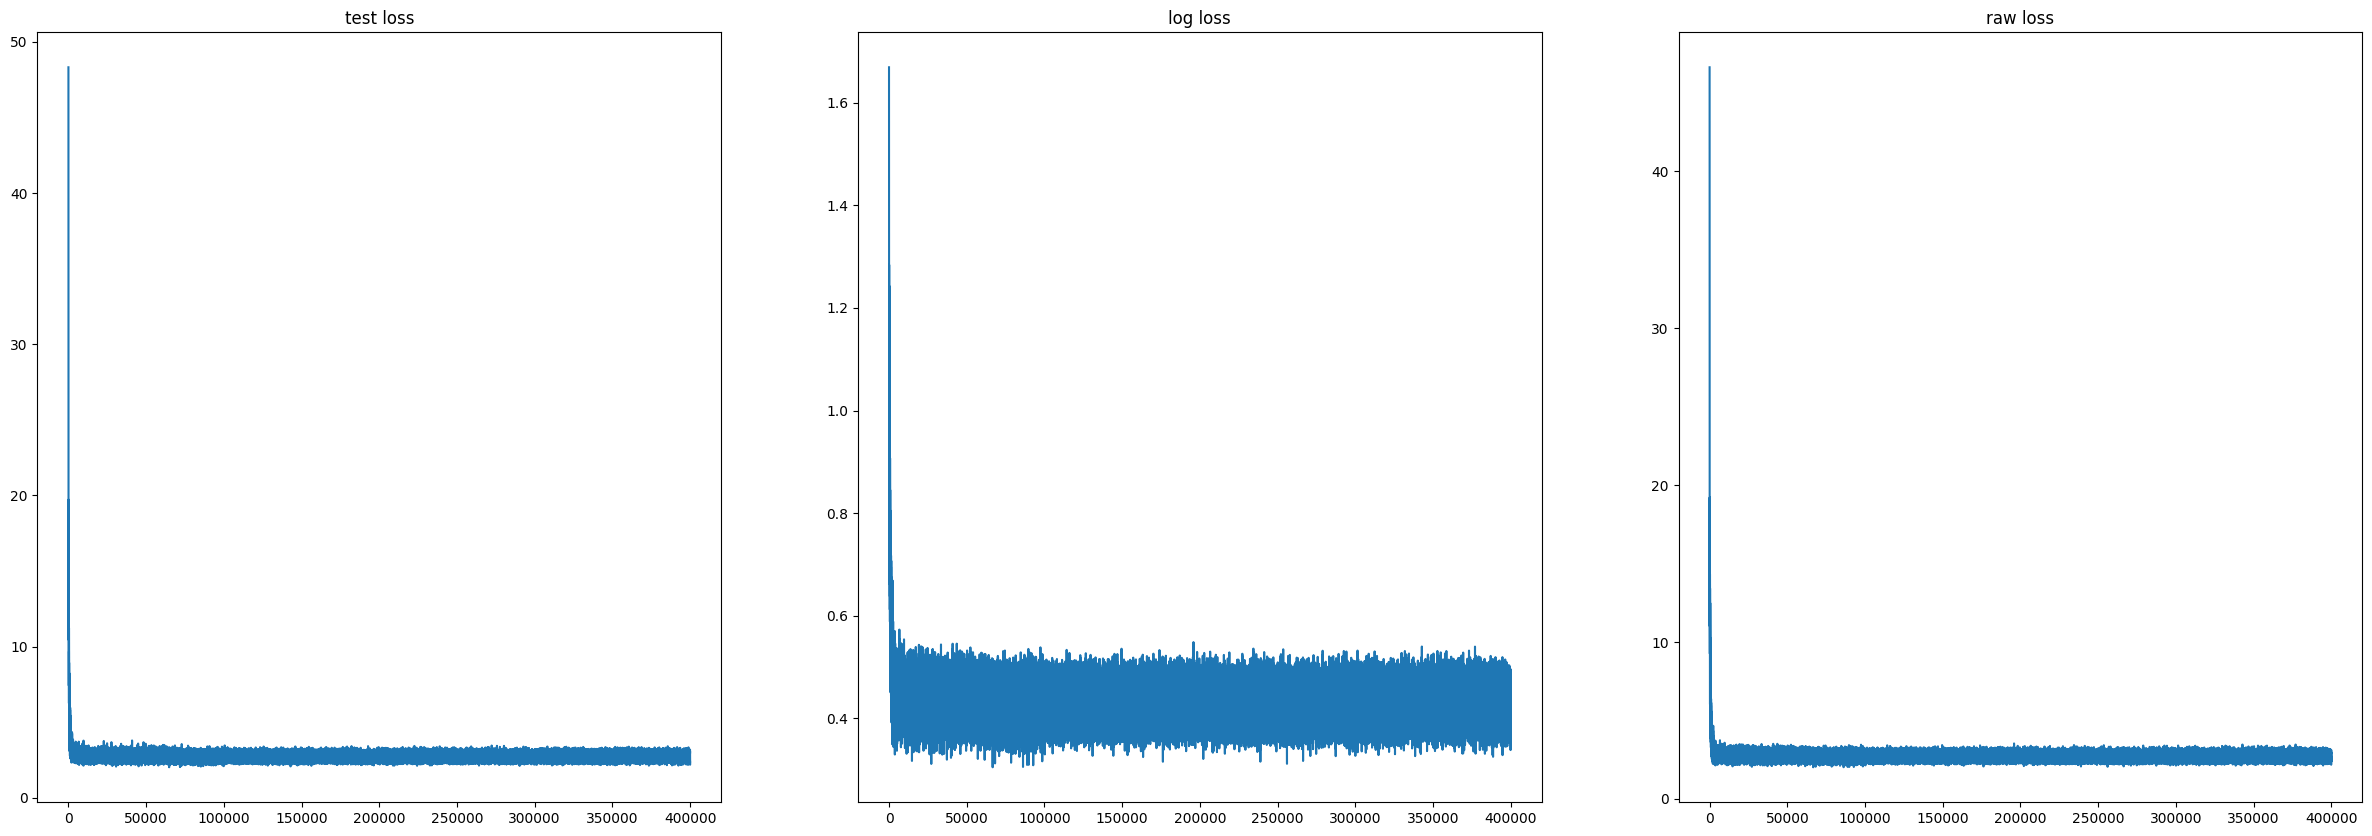

In [12]:
def experiment_instance(
  embed_size = 10,
  dict_size = len(stoi),
  inner_layer_size = 200,
  block_size = 4,
  batch_size = 32,
  lr  = 0.1,
  max_steps = 200000,       
):
  # build the dataset
  block_size = block_size
  def build_dataset(words):
    X, Y = [], []

    for w in words:
      context = [0] * block_size
      for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    # print('dataset shape: ', X.shape, Y.shape)
    return X, Y

  ## make datasets

  random.seed(42)
  random.shuffle(words)

  n1 = int(0.8 * len(words))
  n2 = int(0.9 * len(words))

  # print("Train")
  Xtr, Ytr = build_dataset(words[:n1])
  # print("Dev")
  Xdev, Ydev = build_dataset(words[n1:n2])
  # print("Test")
  Xte, Yte = build_dataset(words[n2:])

  # Model definition
  embed_size = embed_size
  dict_size = dict_size
  inner_layer_size = inner_layer_size

  C = torch.rand(dict_size, embed_size) # embedding matrix

  W1 = torch.randn((block_size * embed_size, inner_layer_size))
  b1 = torch.randn(inner_layer_size)
  
  W4 = torch.randn((inner_layer_size, inner_layer_size))
  b4 = torch.randn(inner_layer_size)

  W3 = torch.randn((inner_layer_size, inner_layer_size))
  b3 = torch.randn(inner_layer_size)

  W2 = torch.randn((inner_layer_size, dict_size))
  b2 = torch.randn(dict_size)

  parameters = [C, W1, b1, W2, b2, W3, b3, W4, b4]


  for p in parameters:
    p.requires_grad = True
  batch_size = batch_size
  lr  = lr
  max_steps = max_steps

  lossi = []
  lossi_raw = []
  test_lossi_raw = []

  for i in range(max_steps):
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    
    #forward pass
    emb = C[Xtr[ix]]
    h_1 = torch.relu(emb.view(-1, block_size*embed_size) @ W1 + b1)
    h_2 = torch.relu(h_1 @ W4 + b4)
    h = torch.tanh(h_2 @ W3 + b3)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, Ytr[ix]) 

    #backward pass
    for p in parameters:
      p.grad = None
    
    loss.backward()
    
    for p in parameters:
      p.data += -lr * p.grad
        
    if i % 1_000 and i < max_steps/2 == 0:
      lr /= 10
    if i % 10_000 and i < max_steps/2 == 0:
      lr *= (10**11)
        
    if i > max_steps/2:
      lr /= 100
    if i > max_steps/4:
      lr /= 10000
    
    torch.no_grad()
    tix = torch.randint(0, Xte.shape[0], (batch_size,))

    temb = C[Xte[tix]]
    h_1 = torch.relu(temb.view(-1, block_size*embed_size) @ W1 + b1)
    h_2 = torch.relu(h_1 @ W4 + b4)
    h = torch.tanh_(h_2 @ W3 + b3)
    logits = h @ W2 + b2
    tloss = F.cross_entropy(logits, Yte[tix]) 

    torch.enable_grad()
    
    #info
    if i % 1000 == 0:
      print(f'TRAIN LOSS: {i:5d}/{max_steps:7d}: {loss.item():.4f}')
      print(f"VALIDATION LOSS: {tloss.item()} \n")
    lossi.append(loss.log10().item())
    lossi_raw.append(loss.item())
    test_lossi_raw.append(tloss.item())
      
  return test_lossi_raw, lossi, lossi_raw

RESULTS = {}

PARAM_LIST = [
  # {
  #   "embed_size" : 40,
  #   "dict_size" : len(stoi),
  #   "inner_layer_size" : 300,
  #   "block_size" : 3,
  #   "batch_size" : 32,
  #   "lr" : 0.01,
  #   "max_steps" : 400_000,
  # }, 
  # 3 hidden layers val 2.6 +- ...
  # {
  #   "embed_size" : 2,
  #   "dict_size" : len(stoi),
  #   "inner_layer_size" : 50,
  #   "block_size" : 3,
  #   "batch_size" : 32,
  #   "lr" : 0.01,
  #   "max_steps" : 400_000,
  # },
  # 3 h, val a little bit smaller, decrease lr after 20000
  # {
  #   "embed_size" : 20,
  #   "dict_size" : len(stoi),
  #   "inner_layer_size" : 100,
  #   "block_size" : 3,
  #   "batch_size" : 32,
  #   "lr" : 0.1,
  #   "max_steps" : 200_000,
  # },
  # дает шансы на существующий тренд, запустим на большее кол-во(200_000 вместо 100_000)
  # импакта 0
  {
    "embed_size" : 40,
    "dict_size" : len(stoi),
    "inner_layer_size" : 300,
    "block_size" : 4,
    "batch_size" : 32,
    "lr" : 0.01,
    "max_steps" : 400_000,
  },
  #тоже самое, кажется, что скрытые доп уровни только делают хуже
  # {
  #   "embed_size" : 40,
  #   "dict_size" : len(stoi),
  #   "inner_layer_size" : 300,
  #   "block_size" : 3,
  #   "batch_size" : 32,
  #   "lr" : 0.01,
  #   "max_steps" : 400_000,
  # },
  # #
  # {
  #   "embed_size" : 40,
  #   "dict_size" : len(stoi),
  #   "inner_layer_size" : 300,
  #   "block_size" : 3,
  #   "batch_size" : 32,
  #   "lr" : 0.01,
  #   "max_steps" : 400_000,
  # },
  # #
  # {
  #   "embed_size" : 40,
  #   "dict_size" : len(stoi),
  #   "inner_layer_size" : 300,
  #   "block_size" : 3,
  #   "batch_size" : 32,
  #   "lr" : 0.01,
  #   "max_steps" : 400_000,
  # },
  # #
]
for EXP_IX, PARAMETERS in enumerate(PARAM_LIST):
  test_lossi_raw, lossi, lossi_raw = experiment_instance(**PARAMETERS)
  RESULTS[EXP_IX] = {
    "test_lossi_raw" : test_lossi_raw,
    "lossi_raw": lossi_raw,
    "lossi": lossi,
    "min_loss":min(lossi_raw),
    "parameters":PARAMETERS,
  }
  
for e_ix, exp in RESULTS.items():
  test_lossi_raw = exp["test_lossi_raw"]
  lossi = exp["lossi"]
  lossi_raw = exp["lossi_raw"]
  fig, ax = plt.subplots(1,3, figsize=(30,10))
  ax[0].plot(test_lossi_raw)
  ax[0].set_title("test loss")
  ax[1].plot(lossi)
  ax[1].set_title("log loss")
  ax[2].plot( [ x for x in lossi_raw if x] )
  ax[2].set_title("raw loss")

SUCCESSFUL_EXPERIMENT = []
for e_ix, exp in RESULTS.items():
  if exp["min_loss"] < 1.8:
    SUCCESSFUL_EXPERIMENT.append(exp)

if len(SUCCESSFUL_EXPERIMENT) > 5:
  print("SUCCESSFUL RESULT IS POSSIBLY GAINED")

In [ ]:
g = torch.Generator().manual_seed(11111)
block_size = 3
num_words = 20
for _ in range(20):
  out = []
  context = [0] * block_size
  # forward pass
  while True:
    emb = C[torch.tensor([context])]
    h = torch.tanh(emb.view(-1, block_size*embed_size) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim = 1)
    ix = torch.multinomial(probs, num_samples = 1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break
  print(''.join(itos[i] for i in out))
  